# Setup

In [1]:
from manim import *
import numpy as np
config.media_width = "75%"
config.verbosity = "WARNING"

# colors

gradient_colors = ["#4E65FF", "#92EFFD"]

Manim Community v0.18.1

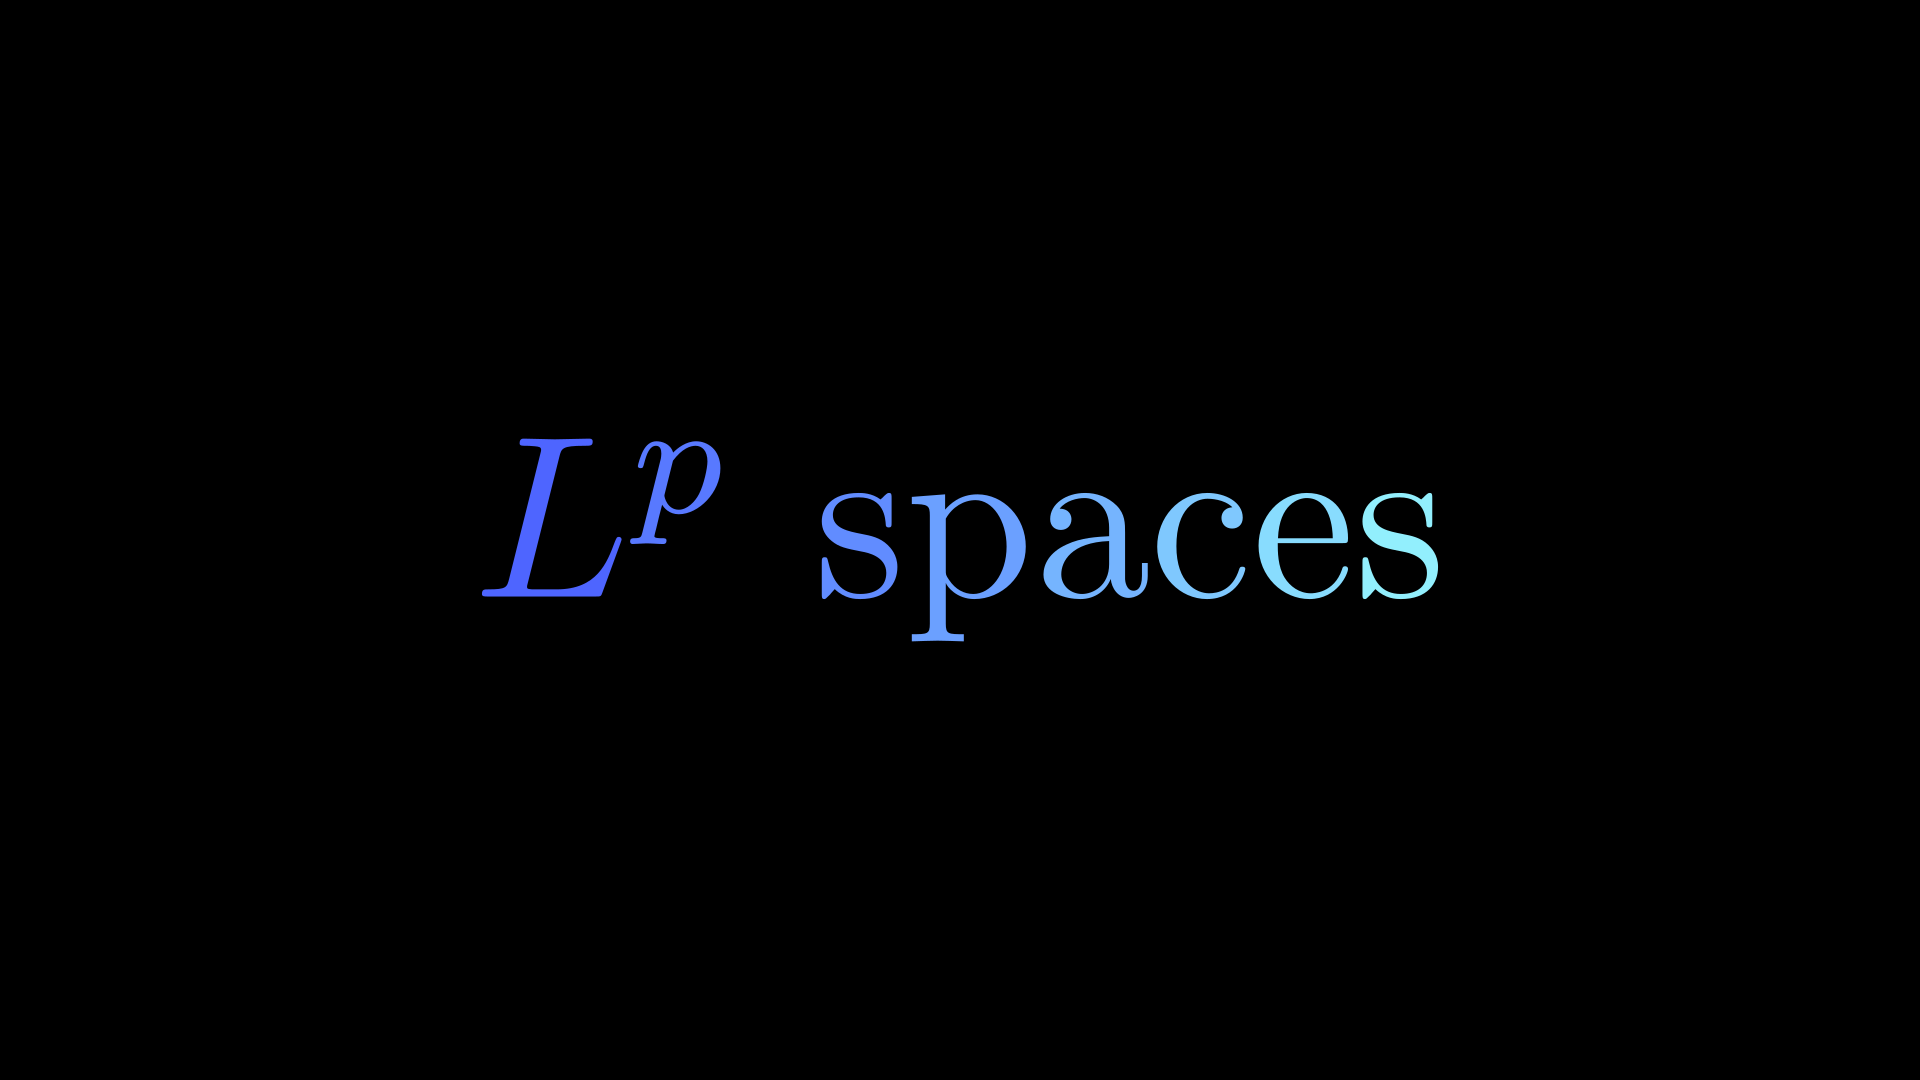

In [13]:
%%manim -qh Thumbnail

class Thumbnail(Scene):
    def construct(self):
        title = Tex("$L^p$ spaces", font_size=165)
        title.set_color_by_gradient(*gradient_colors)
        self.add(title)

Manim Community v0.18.1

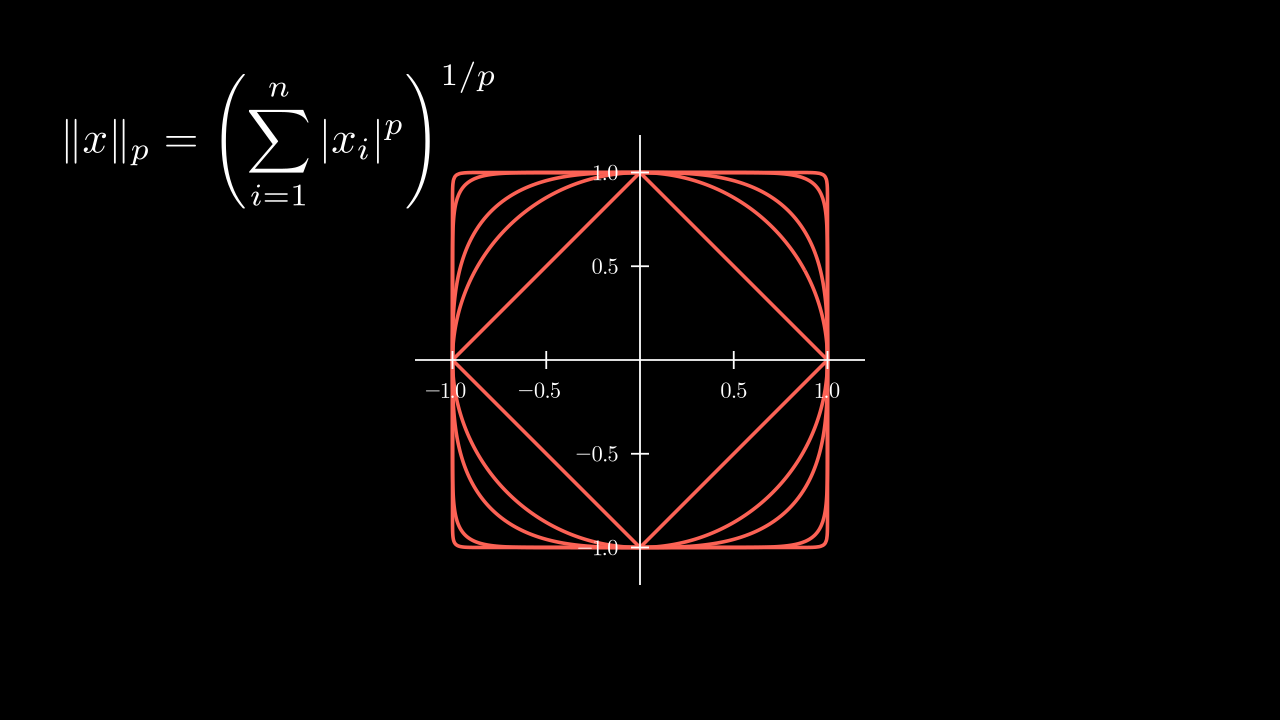

In [49]:
%%manim -qm UnitCircles

class UnitCircles(Scene):
    def construct(self):
        def pnorm(p):
            return lambda x,y : abs(x)**p + abs(y)**p - 1
        
        normtex = MathTex(r"\|x\|_p = \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}")
        normtex.move_to(UP*2.5 + LEFT*4)
    
        axes = Axes(
            x_range = [-1.2, 1.2, 0.5],
            y_range = [-1.2, 1.2, 0.5],
            x_length = 5,
            y_length = 5,
            axis_config = {
                "numbers_to_include": np.arange(-1.0, 1.0 + 0.5, 0.5),
                "font_size": 24,
            },
            tips = False,
        )

        ps = [1, 2, 3, 10, 40]
        for p in ps:
            graph = axes.plot_implicit_curve(
                pnorm(p),
                color=RED
            )
            self.add(graph)
    
        self.add(axes, normtex)

Manim Community v0.18.1

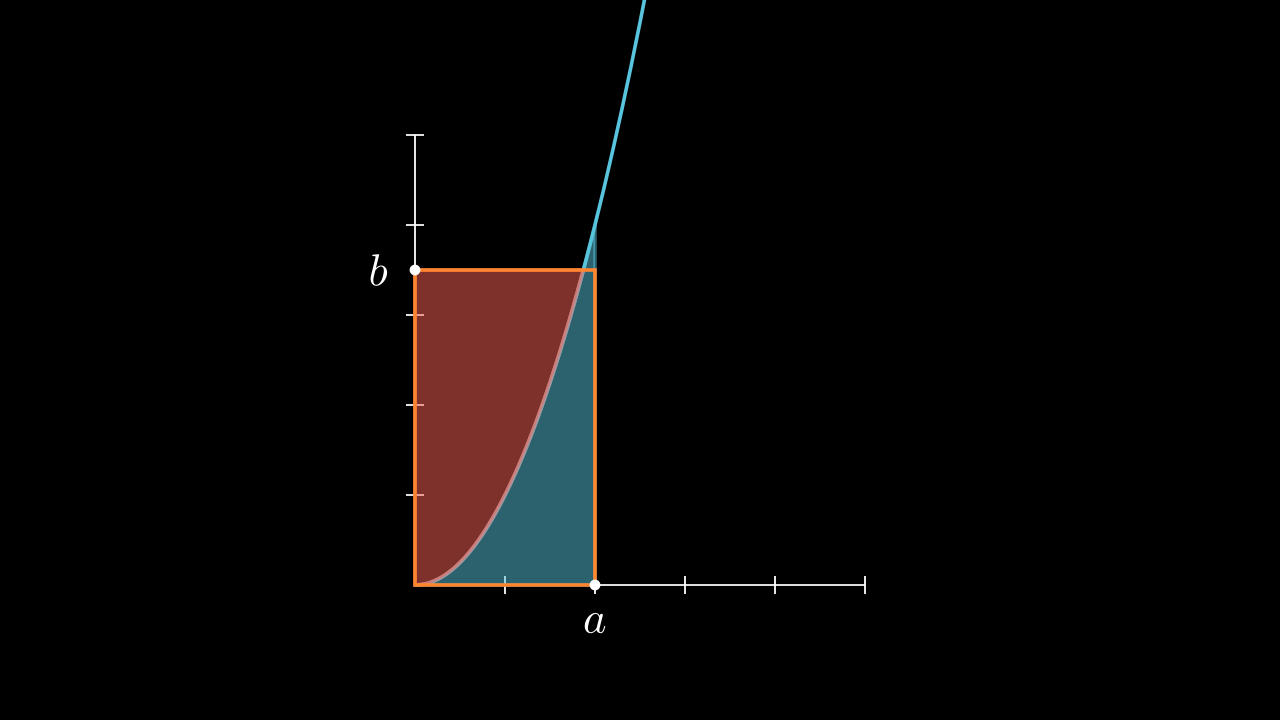

In [128]:
%%manim -qm Young

class Young(Scene):
    def construct(self):
        axes = Axes(
            x_range = [0, 5, 1],
            y_range = [0, 5, 1],
            x_length = 5,
            y_length = 5,
            tips = False
        )

        func = lambda x: x**2
        invers = lambda x: x**(1/2)

        a = 2
        b = 3.5

        curve = axes.plot(
            func,
            color=BLUE
        )
        curve2 = axes.plot(
            lambda x : b
        )

        area1 = axes.get_area(curve, x_range = [0,a], color = BLUE, opacity = 0.5)
        area2 = axes.get_area(curve, x_range=[0, invers(b)], bounded_graph=curve2, color=RED, opacity = 0.5)
        
        pa = Dot(radius = 0.06)
        labela = MathTex("a")
        pa.move_to(axes.c2p(a,0))
        labela.next_to(pa, DOWN)
        pb = Dot(radius = 0.06)
        labelb = MathTex("b")
        pb.move_to(axes.c2p(0,b))
        labelb.next_to(pb, LEFT)
        
        rect = Polygon(axes.c2p(0,0), axes.c2p(a,0), axes.c2p(a,b), axes.c2p(0,b), color = ORANGE)
        
        self.add(axes, curve, area1, area2, rect)

        self.add(pa, pb, labela, labelb)

# Title

In [19]:
%%manim -qm S1

class S1(Scene):
    def construct(self):
        plane = NumberPlane()
        v1 = Vector([1,2])
        normtex = MathTex(r"\|v\| =", "3", font_size = 65)
        normtex.move_to(UP*2.5 + LEFT*5)

        v2 = Vector([-3, 1])
        normtex2 = MathTex(r"\|v\| =", "4", font_size = 65)
        normtex2.move_to(UP*2.5 + LEFT*5)

        v3 = Vector([4, -3])
        normtex3 = MathTex(r"\|v\| =", "7", font_size = 65)
        normtex3.move_to(UP*2.5 + LEFT*5)
        
        self.add(plane)
        self.play(Create(v1))
        self.wait()
        self.play(Write(normtex))
        self.wait()
        self.play(ReplacementTransform(v1, v2), ReplacementTransform(normtex, normtex2))
        self.wait()
        self.play(ReplacementTransform(v2, v3), ReplacementTransform(normtex2, normtex3))
        self.wait()
        self.play(FadeOut(normtex3, v3))

        eucl = MathTex(r"\|v\|_2 = \left(\sum_{i=1}^n v_i^2\right)^{1/2}", font_size = 65)
        eucl.move_to(UP*2.5 + RIGHT*3.5)
        self.play(Write(eucl))
        eucltex = MathTex(r"\|v\|_2 = \sqrt{10}", font_size = 65)
        eucltex.set_color(RED)
        eucltex.move_to(UP*2.5 + LEFT*4)
        line = Line([0,0,0], [-3, 1, 0])
        line.set_color(RED)
        
        self.play(Create(v1))
        self.wait()
        self.play(FadeIn(eucltex, line))
        self.wait(2)
        self.play(FadeOut(eucltex, line, eucl))

        taxi = MathTex(r"\|v\|_1 = \sum_{i=1}^n |v_i|", font_size = 65)
        taxi.move_to(UP*2.5 + RIGHT*3.5)
        self.play(Write(taxi))
        self.wait()
        taxitex = MathTex(r"\|v\|_1 = 4", font_size = 65)
        taxitex.set_color(RED)
        taxitex.move_to(UP*2.5 + LEFT*4)
        line1 = Line([0,0,0], [-3, 0, 0])
        line2 = Line([-3, 0, 0], [-3, 1, 0])
        line1.set_color(RED)
        line2.set_color(RED)
        self.play(FadeIn(taxitex, line1, line2))
        self.wait(2)
        self.play(FadeOut(taxitex, line1, line2, taxi))

        maxi = MathTex(r"\|v\|_\infty = \max_i |v_i|", font_size = 65)
        maxi.move_to(UP*2.5 + RIGHT*3.5)
        self.play(Write(maxi))
        self.wait()
        maxitex = MathTex(r"\|v\|_\infty = 3", font_size=65)
        maxitex.set_color(RED)
        maxitex.move_to(UP*2.5 + LEFT*4)
        self.play(FadeIn(maxitex, line1))
        self.wait(2)
        self.play(FadeOut(maxi, maxitex, line1, v1))

Manim Community v0.18.1

In [22]:
%%manim -qm S2

class S2(Scene):
    def construct(self):
        normtex = Tex(r"""
        \begin{itemize}
        \item $\|v\| \ge 0$, $\|v\| = 0 \Leftrightarrow v = 0$
        \item $\|av\| = a\|v\|$
        \item $\|v+w\| \le \|v\| + \|w\|$
        \end{itemize}
        """)
        normtex.move_to(UP*1.5)
        title = Tex(r"$\leadsto$ ", r"Norm", r" on a vector space over $K \subseteq \mathbb{C}$")
        title[1].set_color(TEAL)
        title.move_to(DOWN*0.5)
        examples = Tex(r"e.g. $\|\cdot\|_1, \|\cdot\|_2, \|\cdot\|_\infty$ on $\mathbb{R}^n$")
        examples.move_to(DOWN*1.5)

        self.play(Write(normtex))
        self.wait()
        self.play(Write(title))
        self.wait()
        self.play(Write(examples))
        self.wait()
        self.play(FadeOut(normtex, title, examples))

Manim Community v0.18.1

In [30]:
%%manim -qm S3

class S3(Scene):
    def construct(self):
        def pnorm(p):
            return lambda x,y : abs(x)**p + abs(y)**p - 1
        
        normtex = MathTex(r"\|x\|_p", r"= \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}")
        normtex.move_to(UP*2.5 + LEFT*4)
        normcon = MathTex(r"1 \le p < \infty")
        normcon.move_to(UP*2.5 + RIGHT*4)
    
        axes = Axes(
            x_range = [-1.2, 1.2, 0.5],
            y_range = [-1.2, 1.2, 0.5],
            x_length = 5,
            y_length = 5,
            axis_config = {
                "numbers_to_include": np.arange(-1.0, 1.0 + 0.5, 0.5),
                "font_size": 24,
            },
            tips = False,
        )

        graph2 = axes.plot_implicit_curve(
            pnorm(2),
            color=RED
        )

        graph1 = axes.plot_implicit_curve(
            pnorm(1),
            color = BLUE
        )

        graphInfinity = axes.plot_implicit_curve(
            lambda x,y: max(abs(x),abs(y)) - 1,
            color = TEAL
        )

        self.play(FadeIn(axes))
        self.wait()
        self.play(Create(graph2))
        self.wait()
        self.play(Create(graph1))
        self.play(Create(graphInfinity))
        self.wait()

        self.play(Write(normtex), Write(normcon))
        
        graph5 = axes.plot_implicit_curve(
            pnorm(1.5),
            color = YELLOW
        )
        graph6 = axes.plot_implicit_curve(
            pnorm(4.5),
            color = ORANGE
        )
        graph7 = axes.plot_implicit_curve(
            pnorm(10),
            color = PINK
        )

        self.play(Create(graph5))
        self.play(Create(graph6))
        self.play(Create(graph7))
        self.wait(2)

        self.play(FadeOut(graph1, graph2, graphInfinity, graph5, graph6, graph7, axes, normtex, normcon))

Manim Community v0.18.1

In [21]:
%%manim -qm S4

class S4(Scene):
    def construct(self):
        functex = MathTex(r"f_v: \{1, \dots, n\} \to \mathbb{R}, k \mapsto v_k")
        functex.move_to(UP*3)
        defnums = MathTex(r"X_n = \{1, \dots, n\}")
        defnums.move_to(UP*2)
        measuretex = Tex(r"$(X_n, \mathcal{P}(X), c)$ ", r"measure space")
        measuretex[1].set_color(TEAL)
        measuretex.move_to(LEFT*3)
        inttexsum = MathTex(r"\int_{X_n} f \, dc = \sum_{i=1}^n f(i)")
        inttexsum.move_to(RIGHT*3)
        normtex = MathTex(r"\|f\|_p = \left(\int_{X_n} |f|^p \, dc\right)^{1/p}")
        normtex.move_to(DOWN*2)

        self.play(Write(functex))
        self.wait()
        self.play(FadeIn(defnums))
        self.wait()
        self.play(FadeIn(measuretex), FadeIn(inttexsum))
        self.wait()
        self.play(Write(normtex))
        self.wait()
        self.play(FadeOut(functex, defnums, measuretex, inttexsum, normtex))

Manim Community v0.18.1

In [16]:
%%manim -qm S5

class S5(Scene):
    def construct(self):
        deftex = Tex(r"$p$-norms", " on $(X, \mathcal{F}, \mu)$")
        deftex[0].set_color_by_gradient(*gradient_colors)
        deftex.move_to(UP*3)
        defnorm = Tex(r"Define $\|f\|_p := \left(\int_X |f|^p\, d\mu\right)^{1/p}$ for $1 \le p < \infty$")
        defnorm.move_to(UP*1.5)
        supnorm = Tex(r"and $\|f\|_\infty := \inf\{C \mid |f| \le C \text{ a.e.}\}$")
        supnorm.move_to(UP*0.5)

        quest1 = Tex(r"Is $\|\cdot\|_p$ a ", r"norm", r" on $\mathcal{L}^p(X,\mu) := \{f:X\to\mathbb{R} \mid \|f\|_p < \infty\}$?")
        quest1[1].set_color(TEAL)
        quest1.move_to(DOWN*1)
        quest2 = Tex(r"Is $\mathcal{L}^p(X,\mu)$ a ", r"vectorspace", r"?")
        quest2[1].set_color(TEAL)
        quest2.move_to(DOWN*2)

        self.play(FadeIn(deftex))
        self.wait()
        self.play(Write(defnorm))
        self.wait(3)
        self.play(Write(supnorm))
        self.wait(2)
        self.play(Write(quest1))
        self.wait()
        self.play(Write(quest2))
        self.wait()
        self.play(FadeOut(deftex, defnorm, supnorm, quest1, quest2))
        

Manim Community v0.18.1

In [18]:
%%manim -qm S6

class S6(Scene):
    def construct(self):
        homotex = Tex(r"Easy to verify $\|af\|_p = |a|\|f\|_p$, \\thus $f \in \mathcal{L}^p(X,\mu) \Rightarrow af \in \mathcal{L}^p(X,mu)$")
        homotex.move_to(UP*2.5)
        questtex = Tex(r"$f+g \in \mathcal{L}^p(X,\mu)$ if $f,g \in \mathcal{L}^p(X,\mu)$?")
        questtex.move_to(UP*1)

        self.play(FadeIn(homotex))
        self.wait()
        self.play(FadeIn(questtex))
        self.wait()
        self.play(FadeOut(homotex))
        self.play(questtex.animate.shift(UP*2))

        defcontex = Tex(r"$h(x) = |x|^p$ is ", r"convex", " in $\mathbb{R}^+$")
        defcontex[1].set_color(TEAL)
        defcontex.move_to(UP*2)
        self.play(Write(defcontex))

        p = 2  # You can change this to any positive value
        x_min, x_max = 0, 3  # Range for the plot (positive real numbers)
        secant_points = [1, 2]  # x-coordinates for secant points
        
        # Axes setup
        axes = Axes(
            x_range=[x_min, x_max, 0.5],
            y_range=[0, 10, 2],
            x_length=6,
            y_length=4,
            axis_config={"color": WHITE},
            tips=False,
        )
        axes.move_to(DOWN*1)
        
        # Plot the function h(x) = |x|^p
        graph = axes.plot(lambda x: x**p, color=BLUE, x_range=[x_min, x_max])
        graph_label = axes.get_graph_label(graph, label="h(x) = |x|^{p}", x_val=2, direction=UP)

        # Secant line points
        x1, x2 = secant_points
        y1, y2 = x1**p, x2**p
        point1 = axes.coords_to_point(x1, y1)
        point2 = axes.coords_to_point(x2, y2)
        
        # Draw the secant line
        secant_line = Line(point1, point2, color=RED)
        
        # Draw dots at the secant points
        dot1 = Dot(point1, color=WHITE)
        dot2 = Dot(point2, color=WHITE)
        
        # Add everything to the scene
        self.play(Create(axes))
        self.play(Create(graph))
        self.play(Create(dot1), Create(dot2))
        self.play(Create(secant_line))
        
        # Wait before ending
        self.wait(2)
        graph = VGroup(axes, graph, dot1, dot2, secant_line)
        self.play(graph.animate.shift(LEFT*3))

        pro1 = MathTex(r"|\frac{1}{2}f + \frac{1}{2}g|^p \le", r"|\frac{1}{2}|f| + \frac{1}{2}|g||^p")
        pro1.move_to(DOWN*0.5 + RIGHT*3.5)
        pro2 = MathTex(r"\frac{1}{2}|f|^p + \frac{1}{2}|g|^p")
        pro2.next_to(pro1[0], RIGHT)
        pro3 = MathTex(r"|f+g|^p \le 2^{p-1}(|f|^p + |g|^p)")
        pro3.move_to(DOWN*0.5 + RIGHT*3.5)
        pro4 = MathTex(r"\|f+g\|_p^p \le 2^{p-1}(\|f\|_p^p + \|g\|_p^p)")
        pro4.move_to(DOWN*0.5 + RIGHT*3.5)
        

        self.play(Write(pro1))
        self.wait()
        self.play(Transform(pro1[1], pro2))
        self.wait()
        self.play(Transform(pro1, pro3))
        self.wait(3)
        self.play(Transform(pro1, pro4))
        self.wait()
        self.play(FadeOut(graph, pro1, defcontex, questtex))

        suptex = MathTex(r"|f+g| \le |f| + |g| \le \|f\|_\infty + \|g\|_\infty \text{ a.e}")
        suptex2 = MathTex(r"\|f+g\|_\infty \le \|f\|_\infty + \|g\|_\infty")

        self.play(Write(suptex))
        self.wait()
        self.play(Transform(suptex, suptex2))
        self.wait()
        self.play(FadeOut(suptex))
        
        vectex = Tex(r"$\leadsto \mathcal{L}^p(X,\mu)$ is a ", r"vector space", " ($1\le p \le \infty$)")
        vectex[1].set_color(TEAL)
        
        self.play(Write(vectex))
        self.wait()
        self.play(FadeOut(vectex))
        

Manim Community v0.18.1

In [19]:
%%manim -qm S7

class S7(Scene):
    def construct(self):
        funcdef = Tex(r"$f$ continuous strictly increasing function ", "$\Rightarrow$ $f^{-1}$ exists")
        funcdef.move_to(UP*3)

        axes = Axes(
            x_range = [0, 5, 1],
            y_range = [0, 5, 1],
            x_length = 5,
            y_length = 5,
            tips = False
        )

        func = lambda x: np.exp(-x/5) * np.sin(np.pi*x/3) + x

        a = 2
        b = 3.5
        a1 = 4
        b1 = 2.5

        curve = axes.plot(
            func,
            color=BLUE
        )
        curve.z_index = 1
        curve2 = axes.plot(
            lambda x : func(b)
        )
        curve3 = axes.plot(
            lambda x : func(b1)
        )

        area1 = axes.get_area(curve, x_range = [0,a], color = BLUE, opacity = 0.5)
        area12 = axes.get_area(curve, x_range = [0,a1], color = BLUE, opacity = 0.5)
        area2 = axes.get_area(curve, x_range=[0, b], bounded_graph=curve2, color=RED, opacity = 0.5)
        area22 = axes.get_area(curve, x_range=[0, b1], bounded_graph=curve3, color=RED, opacity = 0.5)
        
        pa = Dot(radius = 0.06)
        labela = MathTex("a")
        pa.move_to(axes.c2p(a,0))
        labela.next_to(pa, DOWN)
        pb = Dot(radius = 0.06)
        labelb = MathTex("b")
        pb.move_to(axes.c2p(0,func(b)))
        labelb.next_to(pb, LEFT)

        pa1 = Dot(radius = 0.06)
        labela1 = MathTex("a")
        pa1.move_to(axes.c2p(a1,0))
        labela1.next_to(pa1, DOWN)
        pb1 = Dot(radius = 0.06)
        labelb1 = MathTex("b")
        pb1.move_to(axes.c2p(0,func(b1)))
        labelb1.next_to(pb1, LEFT)
        
        rect = Polygon(axes.c2p(0,0), axes.c2p(a,0), axes.c2p(a,func(b)), axes.c2p(0,func(b)), color = ORANGE)
        rect1 = Polygon(axes.c2p(0,0), axes.c2p(a1,0), axes.c2p(a1,func(b)), axes.c2p(0,func(b)), color = ORANGE)
        rect2 = Polygon(axes.c2p(0,0), axes.c2p(a1,0), axes.c2p(a1,func(b1)), axes.c2p(0,func(b1)), color = ORANGE)
        rect.z_index = 2

        self.play(Write(funcdef[0]))
        self.wait()
        self.play(Write(funcdef[1]))
        self.wait()
        self.play(FadeIn(axes))
        self.play(Create(curve))
        self.wait()
        self.play(FadeIn(area1, pa, labela))
        self.wait()
        self.play(FadeIn(area2, pb, labelb))
        self.wait()
        self.play(Create(rect))
        self.wait(2)

        self.play(Transform(pa, pa1), Transform(labela, labela1), Transform(rect, rect1), ReplacementTransform(area1, area12))
        self.wait()
        self.play(Transform(pb, pb1), Transform(labelb, labelb1), Transform(rect, rect2), ReplacementTransform(area2, area22))
        self.wait()

        graph = VGroup(pa, pb, labela, labelb, rect, area12, area22, axes, curve)
        self.play(graph.animate.shift(LEFT*3))

        inequ = MathTex(r"ab \le ", r"\int_0^a f(x)\,dx", "+", r"\int_0^b f^{-1}(x)\,dx")
        inequ[1].set_color(BLUE)
        inequ[3].set_color(RED)
        inequ.move_to(RIGHT*3)

        self.play(Write(inequ))
        self.wait()
        self.play(FadeOut(graph, funcdef))
        self.play(inequ.animate.shift(LEFT*3 + UP*3))
        self.wait()

        young1 = MathTex(r"p,q \in (1,\infty), \frac{1}{p} + \frac{1}{q} = 1,", r"f(x) = x^{p-1}", r",", r"f^{-1}(x) = x^{q-1}")
        young1[1].set_color(BLUE)
        young1[3].set_color(RED)
        young1.move_to(1.5*UP)
        young2 = MathTex(r"ab \le", r"\frac{a^p}{p}", r"+", r"\frac{b^q}{q}")
        young2[1].set_color(BLUE)
        young2[3].set_color(RED)
        young3 = Tex(r"$\leadsto$", r"Young's inequality")
        young3.set_color_by_gradient(*gradient_colors)
        young3.move_to(DOWN*1.5)

        self.play(FadeIn(young1))
        self.wait()
        self.play(Write(young2))
        self.wait()
        self.play(FadeIn(young3))
        self.wait()
        self.play(FadeOut(inequ, young1, young2, young3))

Manim Community v0.18.1

In [4]:
%%manim -qm S8

class S8(Scene):
    def construct(self):
        title = Tex(r"Hölder Inequality")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)
        the1 = MathTex(r"p,q \in [1,\infty], \frac{1}{p} + \frac{1}{q} = 1")
        the1.move_to(UP*2)
        the2 = Tex(r"If $f\in\mathcal{L}^p(X,\mu), g\in\mathcal{L}^q(X,\mu)$, \\then $\int_X |fg|\, d\mu \le \|f\|_p \|g\|_q$")
        the2.move_to(UP*0.5)

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(the1))
        self.wait()
        self.play(Write(the2))
        self.wait()

        pro1 = Tex(r"If $\|f\|_p = 0$ or $\|g\|_q = 0$, then $\int_X |fg|\, d\mu = 0$")
        pro1.move_to(DOWN*1.5)
        self.play(Write(pro1))
        self.wait()
        self.play(FadeOut(pro1))

        pro2 = Tex(r"If $\|f\|_p, \|g\|_q > 0$, then ", r"$\frac{|fg|}{\|f\|_p\|g\|_q} \le \frac{1}{p}\frac{|f|^p}{\|f\|_p^p} + \frac{1}{q}\frac{|g|^p}{\|g\|_p^p}$")
        pro2.move_to(DOWN*1.5 + LEFT*0.5)
        pro3 = Tex(r"$\frac{1}{\|f\|_p\|g\|_q} \int_X |fg|\, d\mu \le \frac{1}{p} + \frac{1}{q} = 1$")
        pro3.next_to(pro2[0], RIGHT)

        self.play(Write(pro2))
        self.wait()
        self.play(Transform(pro2[1], pro3))
        self.wait()
        self.play(FadeOut(title, the1, the2, pro2))

Manim Community v0.18.1

In [8]:
%%manim -qm S9

class S9(Scene):
    def construct(self):
        title = Tex(r"Minkowski inequality")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)
        inequ = Tex(r"If $1\le p < \infty$ and $f,g \in \mathcal{L}^p(X,\mu)$, \\ then $\|f+g\|_p \le \|f\|_p + \|g\|_p$")
        inequ.move_to(UP*1.5)
        pro1 = MathTex(r"\begin{split}\|f+g\|_p^p &\le \int_X (|f|+|g|)|f+g|^{p-1}\,d\mu\\ &\le (\|f\|_p + \|g\|_p)\|(f+g)^{p-1}\|_q\\ &\le (\|f\|_p + \|g\|_p)\|f+g\|_p^{p-1}\end{split}")
        pro1.move_to(DOWN*1.5)
        
        self.play(Write(title))
        self.wait()
        self.play(FadeIn(inequ))
        self.wait()
        self.play(Write(pro1))
        self.wait()
        self.play(FadeOut(title, inequ, pro1))

Manim Community v0.18.1

In [18]:
%%manim -qm S10

class S10(Scene):
    def construct(self):
        prop = MathTex(r"\|f\|_p \ge 0")
        prop.move_to(2.5*UP)
        prop1 = MathTex(r"\|af\|_p = |a|\|f\|_p")
        prop1.move_to(1.5*UP)
        prop2 = MathTex(r"\|f+g\|_p \le \|f\|_p + \|g\|_p")
        prop2.move_to(0.5*UP)
        prop3 = MathTex(r"\|f\|_p = 0 \not\Rightarrow f = 0")
        prop3.move_to(0.5*DOWN)
        prop4 = Tex(r"$\leadsto$", r"$\|\cdot\|_p$ is a semi-norm on $\mathcal{L}^p(X,\mu)$")
        prop4[1].set_color_by_gradient(*gradient_colors)
        prop4.move_to(DOWN*2)

        self.play(Write(prop))
        self.play(Write(prop1))
        self.play(Write(prop2))
        self.wait()
        self.play(Write(prop3))
        self.wait()
        self.play(Write(prop4))
        self.wait()
        self.play(FadeOut(prop, prop1, prop2, prop3, prop4[0]), prop4[1].animate.shift(UP*5))

        defn = MathTex(r"N = \{f:X \to \mathbb{R} \mid \|f\|_p = 0\}")
        defn.move_to(UP*2)
        defLsp = MathTex(r"L^p(X,\mu)", r" := \mathcal{L}^p(X,\mu)/N")
        defLsp[0].set_color_by_gradient(*gradient_colors)
        defLsp.move_to(UP*0.5)
        defNorm = Tex(r"$\|\cdot\|_p$ is a norm on ", r"$L^p(X,\mu)$")
        defNorm[1].set_color_by_gradient(*gradient_colors)
        defNorm.move_to(DOWN*0.7)

        self.play(FadeIn(defn))
        self.wait()
        self.play(Write(defLsp))
        self.wait()
        self.play(Write(defNorm))
        self.wait(3)
        self.play(FadeOut(prop4[1], defn, defLsp, defNorm))

Manim Community v0.18.1

In [4]:
%%manim -qm S11

class S11(Scene):
    def construct(self):
        title = Tex(r"Properties of $L^p(X,\mu)$")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        banach = Tex(r"$L^p(X,\mu)$ is a ", r"Banach space", r".")
        banach[1].set_color(TEAL)
        banach.move_to(UP*2)
        banach1 = Tex(r"If $f_n \in L^p(X, \mu)$ is Cauchy-sequence, then \\there is a $f \in L^p(X,\mu)$ such that $f_n \xrightarrow{n\to\infty} f$.")
        banach1.move_to(UP*0.3)
        banach2 = Tex(r"Moreover, there is a subsequence $f_{n_k}$ such that, \\$f_{n_k} \xrightarrow{k\to\infty} f$ pointwise a.e.")
        banach2.move_to(DOWN*2)

        self.play(FadeIn(title))
        self.wait()
        self.play(Write(banach))
        self.wait()
        self.play(FadeIn(banach1))
        self.wait()
        self.play(FadeIn(banach2))
        self.wait()
        self.play(FadeOut(banach, banach1, banach2))

        sigma1 = Tex(r"Suppose $\mu$ is ", r"$\sigma$-finite", r", $1 \le p < \infty$, $\frac{1}{p} + \frac{1}{q} = 1$")
        sigma1[1].set_color(TEAL)
        sigma1.move_to(UP*2)
        sigma2 = Tex(r"If $f\in L^q(X,\mu)$, define $T_f(g) = \int_X fg\, d\mu$ for $g \in L^p(X,\mu)$")
        sigma2.move_to(UP*0.3)
        sigma3 = Tex(r"$T:L^q(X,\mu) \to (L^p(X,\mu))^*, f \mapsto T_f$ \\is an ", r"isometric isomorphism")
        sigma3[1].set_color(TEAL)
        sigma3.move_to(DOWN*1.5)

        self.play(FadeIn(sigma1))
        self.wait()
        self.play(Write(sigma2))
        self.wait()
        self.play(FadeIn(sigma3))
        self.wait()
        self.play(FadeOut(sigma1, sigma2, sigma3))

        hilbert1 = Tex(r"Special case: $p=2$")
        hilbert1.move_to(UP*1.5)
        hilbert2 = Tex(r"$L^2(X,\mu)$ is a ", r"Hilbert space", r" with $\langle f, g \rangle = \int_X f\overline{g} \,d\mu$")
        hilbert2[1].set_color(TEAL)
        hilbert2.move_to(UP*0.5)
        hilbert3 = Tex(r"Hölder inequality $\leadsto$ Cauchy-Schwarz inequality \\$|\langle f, g \rangle| \le \|f\|_2\|g\|_2$")
        hilbert3.move_to(DOWN*0.7)

        self.play(FadeIn(hilbert1))
        self.wait()
        self.play(Write(hilbert2))
        self.wait(2)
        self.play(FadeIn(hilbert3))
        self.wait()
        self.play(FadeOut(title, hilbert1, hilbert2, hilbert3))
        

Manim Community v0.18.1